In [13]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv("breast-cancer.csv")

In [3]:
X = df.drop("diagnosis", axis=1)
y = df["diagnosis"]

In [4]:
X_train , X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [6]:
pipeline = Pipeline([
    ("Scaler", StandardScaler()),
    ("KNN", KNeighborsClassifier(n_neighbors=5))
])

In [7]:
pipeline.fit(X_train, y_train)

,steps,"[('Scaler', ...), ('KNN', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30


In [8]:
y_pred = pipeline.predict(X_test)

In [9]:
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nAccuracy Score:", accuracy_score(y_test, y_pred))

Confusion Matrix:
 [[68  3]
 [ 3 40]]

Classification Report:
               precision    recall  f1-score   support

           B       0.96      0.96      0.96        71
           M       0.93      0.93      0.93        43

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114


Accuracy Score: 0.9473684210526315


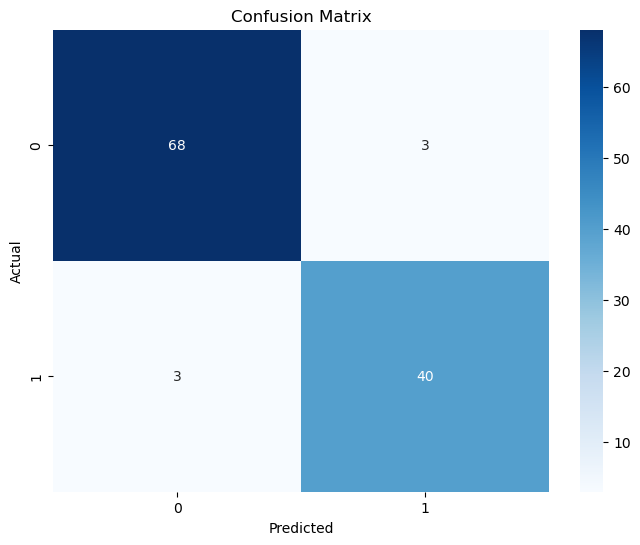

In [11]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d',cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
cv_scores = cross_val_score(pipeline, X, y, cv=5,scoring='accuracy')
print(cv_scores)
print("Average Accuracy: ", cv_scores.mean())

[0.97368421 0.95614035 0.98245614 0.95614035 0.95575221]
Average Accuracy:  0.964834653004192
